<a href="https://colab.research.google.com/github/PihuCodeTech/Aircraft-Engine-RUL-Prediction/blob/main/notebooks/OriginalTCN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL A — Run this cell ALONE first
# ══════════════════════════════════════════════════════════════════════════════
!pip install optuna -q
print("Optuna ready.")

Optuna ready.


In [3]:
import numpy as np, random, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor
import tensorflow as tf
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

SEQ_LEN = 40

DATASET_CONFIG = {
    'FD001': {'rul_threshold':125, 'multi_condition':False},
    'FD002': {'rul_threshold':125, 'multi_condition':True},
    'FD003': {'rul_threshold':125, 'multi_condition':False},
    'FD004': {'rul_threshold':125, 'multi_condition':True},
}

# ── Change this path to where your files are ──────────────────────────────────
DATA_PATH = '/content/'   # Colab: files uploaded to content folder
# DATA_PATH = './'        # if files are in same folder as notebook

def load_data(dataset):
    cols     = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
    train_df = pd.read_csv(f"{DATA_PATH}train_{dataset}.txt",
                           sep=r"\s+", header=None)
    train_df.columns = cols
    test_df  = pd.read_csv(f"{DATA_PATH}test_{dataset}.txt",
                           sep=r"\s+", header=None)
    test_df.columns  = cols
    y_test   = pd.read_csv(f"{DATA_PATH}RUL_{dataset}.txt",
                           header=None).values.flatten()
    return train_df, test_df, y_test

#def mlp_condition_normalize(train_df, test_df, sensor_cols):
    train_df = train_df.copy(); test_df = test_df.copy()
    for col in sensor_cols:
        mlp = MLPRegressor(hidden_layer_sizes=(16,), max_iter=500,
                           random_state=SEED, alpha=0.01)
        mlp.fit(train_df[['op1','op2','op3']], train_df[col])
        train_df[col] = train_df[col] - mlp.predict(train_df[['op1','op2','op3']])
        test_df[col]  = test_df[col]  - mlp.predict(test_df[['op1','op2','op3']])
    return train_df, test_df

def preprocess(train_df, test_df, dataset):
    cfg = DATASET_CONFIG[dataset]
    max_cycle         = train_df.groupby('id')['cycle'].max().reset_index()
    max_cycle.columns = ['id','max_cycle']
    train_df          = train_df.merge(max_cycle, on='id')
    train_df['RUL']   = (train_df['max_cycle'] - train_df['cycle']).clip(upper=cfg['rul_threshold'])
    train_df.drop(columns=['max_cycle'], inplace=True)
    feature_cols = [c for c in train_df.columns if c not in ['id','RUL']]
    sensor_cols  = [c for c in feature_cols if c.startswith('s')]
    #if cfg['multi_condition']:
        #train_df, test_df = mlp_condition_normalize(train_df, test_df, sensor_cols)
    scaler = MinMaxScaler(feature_range=(0,1))
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols]  = scaler.transform(test_df[feature_cols])
    return train_df, test_df, feature_cols

def create_sequences(df, feature_cols, seq_len):
    X_seqs, y_seqs = [], []
    for eid in df['id'].unique():
        data = df[df['id'] == eid][feature_cols + ['RUL']].values
        for i in range(len(data) - seq_len):
            X_seqs.append(data[i:i+seq_len, :-1])
            y_seqs.append(data[i+seq_len, -1])
    return np.array(X_seqs, dtype=np.float32), np.array(y_seqs, dtype=np.float32)

def create_test_sequences(test_df, feature_cols, seq_len):
    X_test = []
    for eid in test_df['id'].unique():
        ed = test_df[test_df['id'] == eid][feature_cols].values
        if len(ed) < seq_len:
            pad = np.zeros((seq_len - len(ed), ed.shape[1]))
            ed  = np.vstack([pad, ed])
        else:
            ed  = ed[-seq_len:]
        X_test.append(ed)
    return np.array(X_test, dtype=np.float32)

def nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    return float(np.sum(np.where(diff < 0, np.exp(-diff/13)-1, np.exp(diff/10)-1)))

def report_metrics(name, true, pred):
    mse  = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(true, pred)
    nasa = nasa_score(true, pred)
    print(f"{name:40s} MSE={mse:.3f} RMSE={rmse:.3f} MAE={mae:.3f} NASA={nasa:.1f}")
    return rmse, mae, mse, nasa

def plot_loss(h, name, ds):
    plt.figure(figsize=(10,5))
    plt.plot(h.history['loss'],     label='Train Loss')
    plt.plot(h.history['val_loss'], label='Val Loss')
    plt.title(f'{name} — Loss vs Epoch ({ds})')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(); plt.show()

def plot_predictions(y_test, pred, name, ds):
    plt.figure(figsize=(14,5))
    plt.plot(y_test, label='Actual RUL', linewidth=2, color='black')
    plt.plot(pred,   label=f'{name} Predicted', linewidth=1.5,
             color='blue', alpha=0.8)
    plt.title(f'Actual vs Predicted RUL — {name} ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('RUL')
    plt.legend(); plt.grid(); plt.show()

def plot_residuals(y_test, pred, name, ds):
    res = y_test - pred
    plt.figure(figsize=(10,4))
    plt.scatter(range(len(res)), res, alpha=0.6, color='steelblue')
    plt.axhline(0, linestyle='--', color='black')
    plt.title(f'Residuals — {name} ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('Residual')
    plt.grid(); plt.show()

def plot_rmse_bar(results_dict, model_name):
    datasets  = list(results_dict.keys())
    rmse_vals = [results_dict[ds]['rmse'] for ds in datasets]
    plt.figure(figsize=(8,5))
    bars = plt.bar(datasets, rmse_vals, color='steelblue', edgecolor='white')
    plt.bar_label(bars, fmt='%.3f', padding=3)
    plt.title(f'{model_name} — Test RMSE Across Datasets')
    plt.ylabel('RMSE'); plt.grid(axis='y'); plt.show()

def plot_rul_dist(train_df, ds):
    plt.figure(figsize=(10,5))
    plt.hist(train_df['RUL'], bins=40, color='steelblue', edgecolor='white')
    plt.title(f'RUL Distribution — {ds}')
    plt.xlabel('RUL'); plt.ylabel('Frequency')
    plt.grid(); plt.show()

# Quick check that files load correctly
print("Testing data loading...")
for ds in ['FD001','FD002','FD003','FD004']:
    tr, te, y = load_data(ds)
    print(f"  {ds}: train={tr.shape} test={te.shape} y_test={y.shape}")
print("All datasets loaded successfully.")

Testing data loading...
  FD001: train=(20631, 26) test=(13096, 26) y_test=(100,)
  FD002: train=(53759, 26) test=(33991, 26) y_test=(259,)
  FD003: train=(24720, 26) test=(16596, 26) y_test=(100,)
  FD004: train=(61249, 26) test=(41214, 26) y_test=(248,)
All datasets loaded successfully.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL B — TCN SEARCH FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout,
    GlobalAveragePooling1D, LayerNormalization,
    MultiHeadAttention, Add, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber

def get_cbs_tcn(hp):
    return [
        EarlyStopping(monitor='val_loss', patience=hp['patience_es'],
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=hp['lr_factor'],
                          patience=hp['patience_lr'],
                          min_lr=hp['min_lr'], verbose=1)
    ]

def tcn_block_search(x, filters, kernel_size, dilation_rate, dropout):
    residual = x
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation_rate, activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(dropout)(x)
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation_rate, activation='relu')(x)
    x = BatchNormalization()(x)
    if residual.shape[-1] != filters:
        residual = Conv1D(filters, 1, padding='same')(residual)
    return Add()([x, residual])

def build_tcn_search(seq_len, n_features, hp):
    inputs = Input(shape=(seq_len, n_features))
    x      = inputs
    for d in hp['dilations']:
        x = tcn_block_search(x, hp['filters'], hp['kernel_size'], d, hp['dropout'])
    attn = MultiHeadAttention(num_heads=hp['attn_heads'],
                              key_dim=hp['attn_key_dim'],
                              dropout=0.05)(x, x)
    x    = LayerNormalization()(Add()([x, attn]))
    x    = GlobalAveragePooling1D()(x)
    x    = Dense(hp['dense_units'], activation='relu')(x)
    x    = Dropout(hp['dropout'])(x)
    out  = Dense(1)(x)
    m    = Model(inputs, out)
    m.compile(optimizer=Adam(hp['lr'], clipnorm=1.0),
              loss=Huber(), metrics=['mae'])
    return m

# Candidate dilation schedules
DILATION_OPTIONS = [
    [1, 2, 4, 8],
    [1, 2, 4, 8, 16],
    [2, 4, 6, 8],
    [2, 4, 8, 16],
    [1, 2, 4],
    [2, 4, 8],
    [1, 2, 4, 8, 16, 32],
]

TCN_SPACE = {
    'filters'    : [32, 64, 128],
    'kernel_size': [2, 3, 4],
    'attn_heads' : [2, 4, 8],
    'attn_key_dim': [8, 16, 32, 64],
    'dense_units': [32, 64, 128],
    'dropout'    : (0.05, 0.40),
    'lr'         : (1e-4, 1e-2),
    'batch_size' : [16, 32, 64, 128],
}

def sample_tcn_hp(epochs_search=60):
    hp = {'dilations': random.choice(DILATION_OPTIONS)}
    for k, v in TCN_SPACE.items():
        if isinstance(v, list):
            hp[k] = random.choice(v)
        elif k == 'dropout':
            hp[k] = round(random.uniform(*v), 3)
        elif k == 'lr':
            hp[k] = float(10 ** random.uniform(np.log10(v[0]), np.log10(v[1])))
    hp.update({'epochs': epochs_search, 'patience_es': 12,
               'patience_lr': 5, 'lr_factor': 0.5, 'min_lr': 1e-7})
    return hp

def quick_tcn(hp, dataset='FD001'):
    np.random.seed(SEED); tf.random.set_seed(SEED)
    tr, _, _                   = load_data(dataset)
    train_df, _, feature_cols  = preprocess(tr.copy(), tr.copy(), dataset)
    eids                       = train_df['id'].unique()
    tr_e, val_e                = train_test_split(eids, test_size=0.2, random_state=SEED)
    Xtr, ytr   = create_sequences(train_df[train_df['id'].isin(tr_e)], feature_cols, SEQ_LEN)
    Xval, yval = create_sequences(train_df[train_df['id'].isin(val_e)], feature_cols, SEQ_LEN)
    nf  = Xtr.shape[2]
    m   = build_tcn_search(SEQ_LEN, nf, hp)
    m.fit(Xtr, ytr, validation_data=(Xval, yval),
          epochs=hp['epochs'], batch_size=hp['batch_size'],
          callbacks=get_cbs_tcn(hp), verbose=0)
    vp   = m.predict(Xval, verbose=0).flatten()
    rmse = float(np.sqrt(mean_squared_error(yval, vp)))
    tf.keras.backend.clear_session()
    return rmse

def tcn_random_search(n_trials=20, dataset='FD001', epochs_search=60):
    print(f"\n{'═'*60}\n  TCN RANDOM SEARCH — {n_trials} trials on {dataset}"
          f" (epochs={epochs_search})\n{'═'*60}")
    best_hp, best_rmse = None, np.inf; log = []
    for t in range(1, n_trials + 1):
        hp = sample_tcn_hp(epochs_search)
        try:
            r = quick_tcn(hp, dataset)
            log.append({'trial': t, 'hp': hp.copy(), 'val_rmse': r})
            if r < best_rmse:
                best_rmse = r; best_hp = hp.copy()
                print(f"  Trial {t:3d}: {r:.3f} ← BEST | "
                      f"filt={hp['filters']} k={hp['kernel_size']} "
                      f"dil={hp['dilations']} heads={hp['attn_heads']} "
                      f"dr={hp['dropout']:.2f} lr={hp['lr']:.1e}")
            else:
                print(f"  Trial {t:3d}: {r:.3f}")
        except Exception as e:
            print(f"  Trial {t:3d}: FAILED — {e}")
    log.sort(key=lambda x: x['val_rmse'])
    print(f"\n  Top 3:")
    for entry in log[:3]:
        h = entry['hp']
        print(f"    Trial {entry['trial']:3d}: Val RMSE={entry['val_rmse']:.3f} | "
              f"filt={h['filters']} dil={h['dilations']} lr={h['lr']:.1e}")
    print(f"\n  Best val RMSE: {best_rmse:.3f}")
    return best_hp, log

def tcn_bayesian_opt(n_trials=50, dataset='FD001', epochs_search=60):
    print(f"\n{'═'*60}\n  TCN BAYESIAN OPT — {n_trials} trials on {dataset}"
          f" (epochs={epochs_search})\n{'═'*60}")
    DIL_IDX = list(range(len(DILATION_OPTIONS)))

    def objective(trial):
        hp = {
            'filters'    : trial.suggest_categorical('filters',     [32, 64, 128]),
            'kernel_size': trial.suggest_categorical('kernel_size',  [2, 3, 4]),
            'dilations'  : DILATION_OPTIONS[trial.suggest_categorical('dil_idx', DIL_IDX)],
            'attn_heads' : trial.suggest_categorical('attn_heads',   [2, 4, 8]),
            'attn_key_dim': trial.suggest_categorical('attn_key_dim',[8,16,32,64]),
            'dense_units': trial.suggest_categorical('dense_units',  [32, 64, 128]),
            'dropout'    : trial.suggest_float('dropout', 0.05, 0.40),
            'lr'         : trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size' : trial.suggest_categorical('batch_size',   [16,32,64,128]),
            'epochs': epochs_search, 'patience_es': 12,
            'patience_lr': 5, 'lr_factor': 0.5, 'min_lr': 1e-7,
        }
        return quick_tcn(hp, dataset)

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best = study.best_trial
    print(f"\n  Best trial #{best.number}: Val RMSE={best.value:.3f}")
    print(f"  Best params: {best.params}")

    try:
        imp = optuna.importance.get_param_importances(study)
        plt.figure(figsize=(10, 5))
        plt.barh(list(imp.keys()), list(imp.values()), color='steelblue')
        plt.title('HP Importance — TCN (Optuna TPE)')
        plt.xlabel('Importance Score'); plt.tight_layout()
        plt.grid(axis='x'); plt.show()
    except Exception:
        pass

    p = best.params
    best_hp = {
        'filters'    : p['filters'],
        'kernel_size': p['kernel_size'],
        'dilations'  : DILATION_OPTIONS[p['dil_idx']],
        'attn_heads' : p['attn_heads'],
        'attn_key_dim': p['attn_key_dim'],
        'dense_units': p['dense_units'],
        'dropout'    : p['dropout'],
        'lr'         : p['lr'],
        'batch_size' : p['batch_size'],
        'epochs': 100, 'patience_es': 25,
        'patience_lr': 6, 'lr_factor': 0.5, 'min_lr': 1e-7,
    }
    return best_hp, study

print("TCN search functions loaded. Run Cell C next.")

TCN search functions loaded. Run Cell C next.


In [4]:
# CELL C — Phase 1: Random Search
best_hp_rs_tcn, rs_log_tcn = tcn_random_search(
    n_trials=20, dataset='FD001', epochs_search=60)
print(f"\nBest RS HP: {best_hp_rs_tcn}")


════════════════════════════════════════════════════════════
  TCN RANDOM SEARCH — 20 trials on FD001 (epochs=60)
════════════════════════════════════════════════════════════

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0014856361085548997.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0007428180542774498.
  Trial   1: 11.438 ← BEST | filt=32 k=2 dil=[2, 4, 8] heads=8 dr=0.13 lr=3.0e-03

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.00013477134052664042.

Epoch 16: ReduceLROnPlateau reducing learning rate to 6.738567026332021e-05.
  Trial   2: 12.755

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0010507432743906975.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005253716371953487.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.00026268581859767437.
  Trial   3: 12.376

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.00017332677089143544.

Epoch 22: ReduceLROnPlateau reducing learning rate to 8.666338544571772e-05


════════════════════════════════════════════════════════════
  TCN BAYESIAN OPT — 20 trials on FD001 (epochs=60)
════════════════════════════════════════════════════════════


  0%|          | 0/20 [00:00<?, ?it/s]


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0004084227839484811.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.00020421139197424054.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0030805247370153666.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0015402623685076833.

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0007701311842538416.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002294912119396031.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.00011474560596980155.

Epoch 35: ReduceLROnPlateau reducing learning rate to 5.737280298490077e-05.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.00010505399404792115.

Epoch 28: ReduceLROnPlateau reducing learning rate to 5.2526997023960575e-05.

Epoch 33: ReduceLROnPlateau reducing learning rate to 2.6263498511980288e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.004205954726785421.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.002

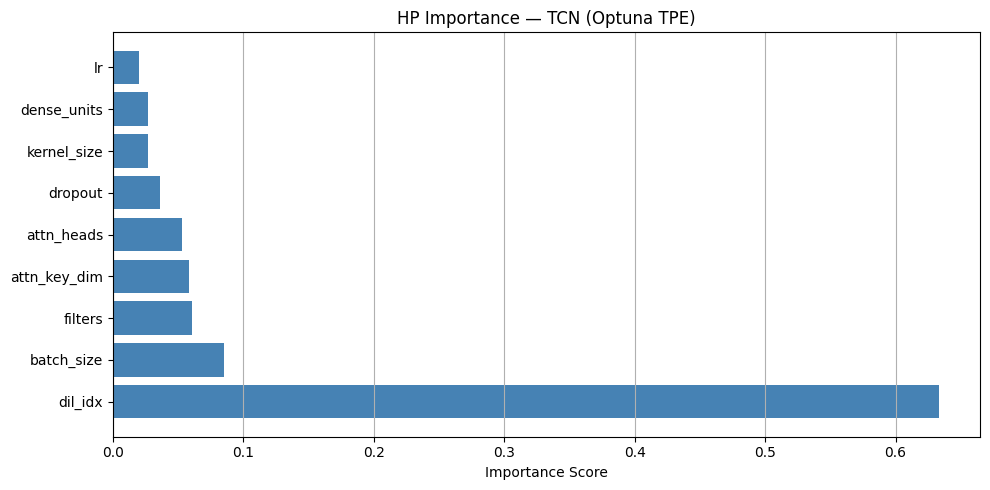


Best BO HP: {'filters': 64, 'kernel_size': 4, 'dilations': [2, 4, 8, 16], 'attn_heads': 4, 'attn_key_dim': 16, 'dense_units': 32, 'dropout': 0.06427129954416738, 'lr': 0.0015197980620034217, 'batch_size': 16, 'epochs': 100, 'patience_es': 25, 'patience_lr': 6, 'lr_factor': 0.5, 'min_lr': 1e-07}


In [5]:
# CELL D — Phase 2: Bayesian Optimization
best_hp_bo_tcn, study_tcn = tcn_bayesian_opt(
    n_trials=20, dataset='FD001', epochs_search=60)
print(f"\nBest BO HP: {best_hp_bo_tcn}")


███████████████████████████████████████████████████████
  TCN OPTIMIZED | FD001
███████████████████████████████████████████████████████

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0007598990341648459.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.00037994951708242297.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.00018997475854121149.

Epoch 35: ReduceLROnPlateau reducing learning rate to 9.498737927060574e-05.

  Validation:
  TCN Optimized                          MSE=121.256 RMSE=11.012 MAE=7.649 NASA=6109.3
  Test:
  TCN Optimized                          MSE=235.037 RMSE=15.331 MAE=11.013 NASA=467.4


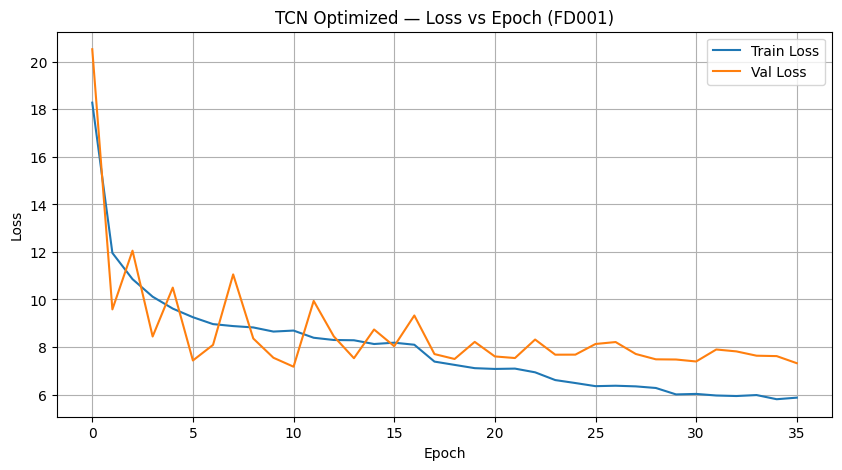

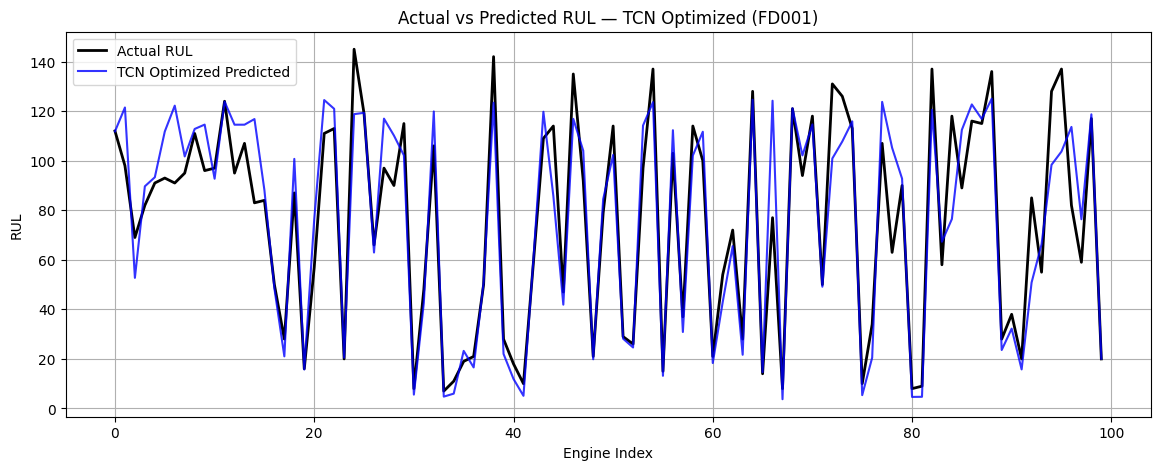

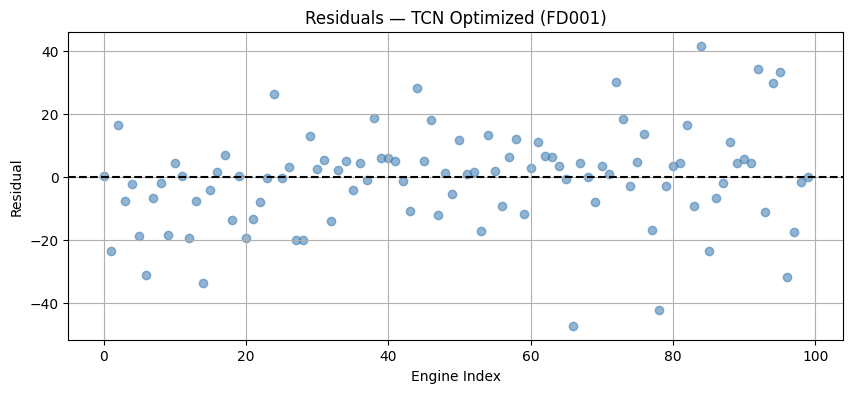


███████████████████████████████████████████████████████
  TCN OPTIMIZED | FD002
███████████████████████████████████████████████████████

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0007598990341648459.

Epoch 36: ReduceLROnPlateau reducing learning rate to 0.00037994951708242297.

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.00018997475854121149.

Epoch 50: ReduceLROnPlateau reducing learning rate to 9.498737927060574e-05.

Epoch 58: ReduceLROnPlateau reducing learning rate to 4.749368963530287e-05.

Epoch 64: ReduceLROnPlateau reducing learning rate to 2.3746844817651436e-05.

Epoch 70: ReduceLROnPlateau reducing learning rate to 1.1873422408825718e-05.

Epoch 76: ReduceLROnPlateau reducing learning rate to 5.936711204412859e-06.

  Validation:
  TCN Optimized                          MSE=273.545 RMSE=16.539 MAE=11.480 NASA=55837.0
  Test:
  TCN Optimized                          MSE=747.099 RMSE=27.333 MAE=18.798 NASA=6618.4


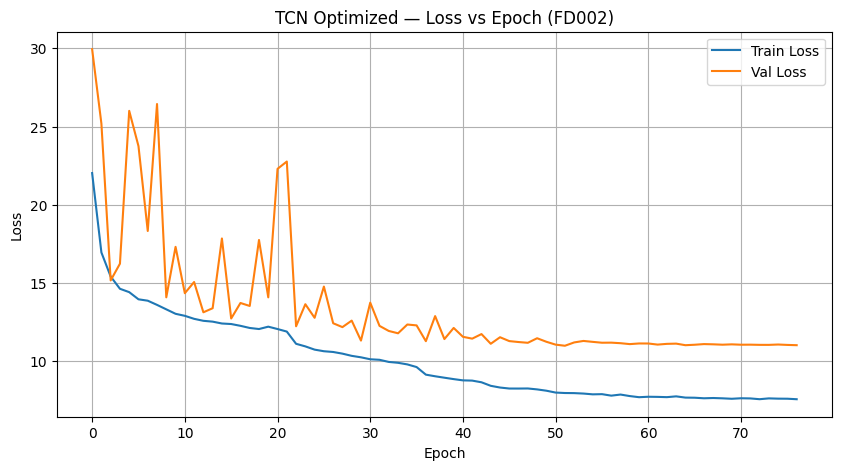

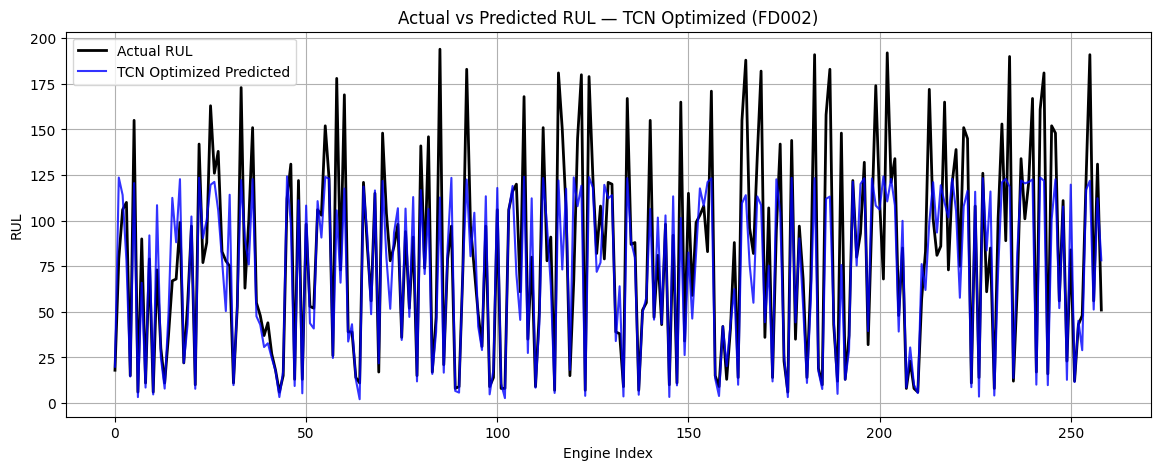

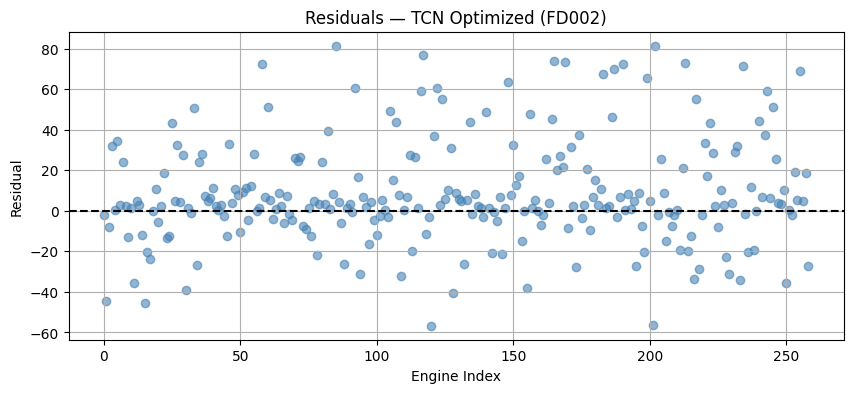


███████████████████████████████████████████████████████
  TCN OPTIMIZED | FD003
███████████████████████████████████████████████████████

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0007598990341648459.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.00037994951708242297.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.00018997475854121149.

Epoch 46: ReduceLROnPlateau reducing learning rate to 9.498737927060574e-05.

Epoch 52: ReduceLROnPlateau reducing learning rate to 4.749368963530287e-05.

Epoch 58: ReduceLROnPlateau reducing learning rate to 2.3746844817651436e-05.

  Validation:
  TCN Optimized                          MSE=119.358 RMSE=10.925 MAE=6.544 NASA=8990.4
  Test:
  TCN Optimized                          MSE=230.753 RMSE=15.191 MAE=10.323 NASA=666.3


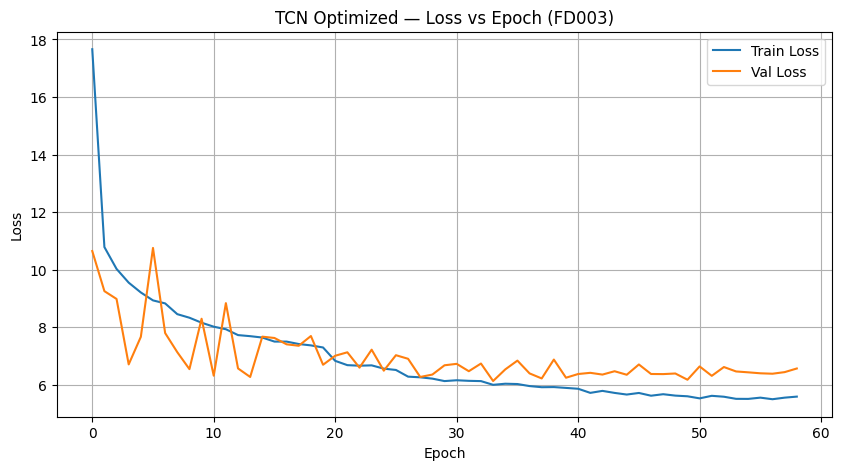

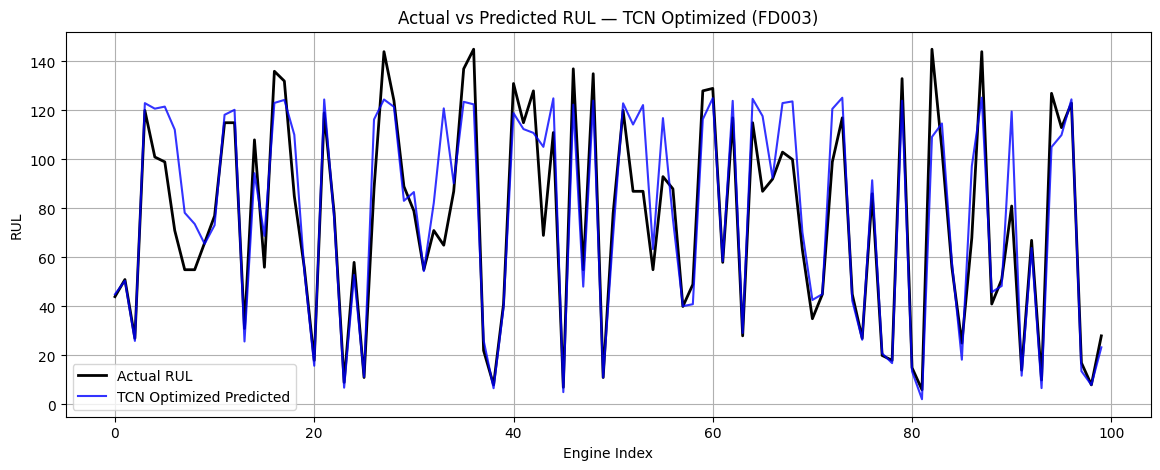

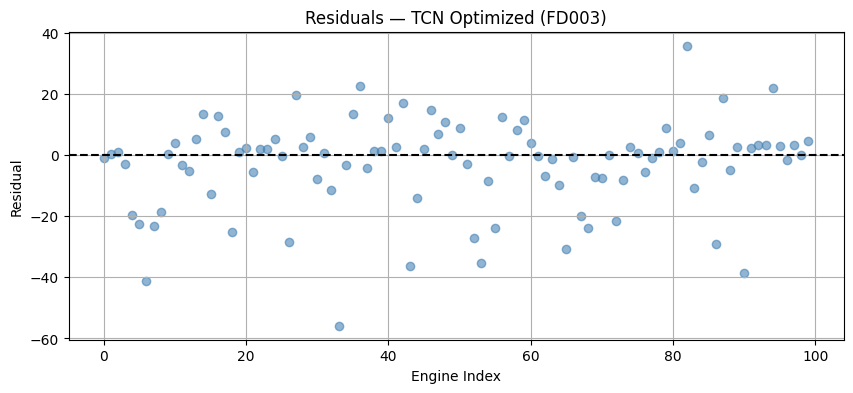


███████████████████████████████████████████████████████
  TCN OPTIMIZED | FD004
███████████████████████████████████████████████████████

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0007598990341648459.

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.00037994951708242297.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.00018997475854121149.

Epoch 46: ReduceLROnPlateau reducing learning rate to 9.498737927060574e-05.

Epoch 52: ReduceLROnPlateau reducing learning rate to 4.749368963530287e-05.

Epoch 58: ReduceLROnPlateau reducing learning rate to 2.3746844817651436e-05.

  Validation:
  TCN Optimized                          MSE=390.334 RMSE=19.757 MAE=12.461 NASA=159571.5
  Test:
  TCN Optimized                          MSE=821.933 RMSE=28.669 MAE=20.534 NASA=8423.5


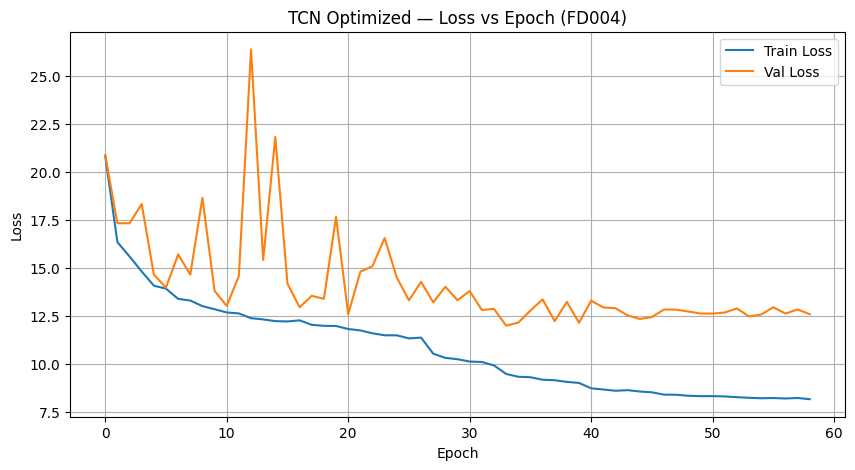

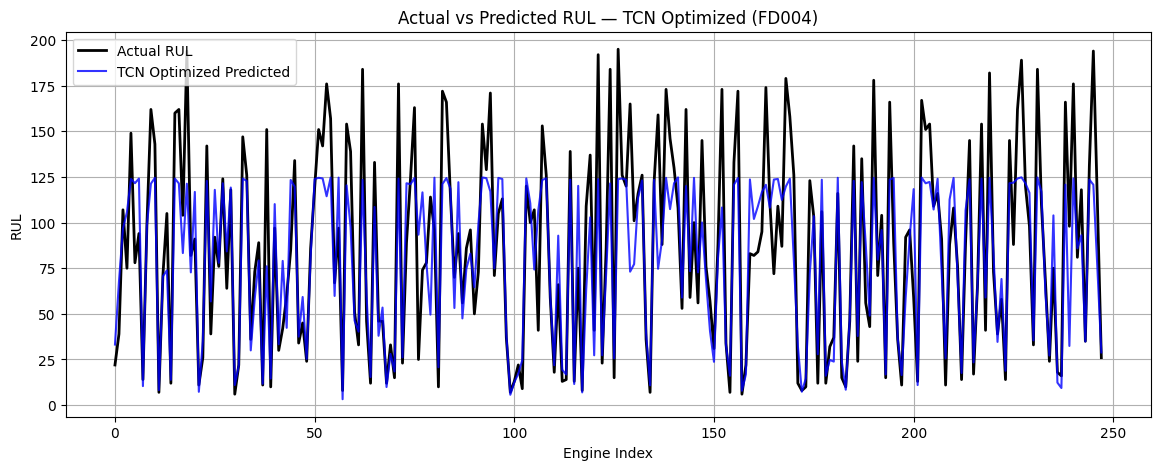

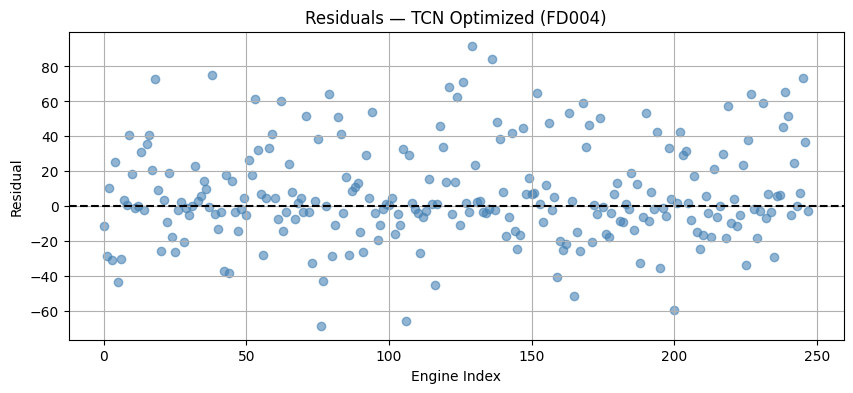


═════════════════════════════════════════════════════════════════
  TCN: Baseline vs Optimized
═════════════════════════════════════════════════════════════════
  Dataset        Baseline    Optimized   Change
  ────────── ──────────── ──────────── ────────


NameError: name 'all_results' is not defined

In [6]:
# CELL E — Retrain best HP all datasets
DATASETS      = ['FD001','FD002','FD003','FD004']
best_hp       = best_hp_bo_tcn.copy()
best_hp['epochs']      = 100
best_hp['patience_es'] = 25
optimized_tcn = {}

for dataset in DATASETS:
    print(f"\n{'█'*55}\n  TCN OPTIMIZED | {dataset}\n{'█'*55}")
    np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

    train_raw, test_raw, y_test     = load_data(dataset)
    train_df, test_df, feature_cols = preprocess(
        train_raw.copy(), test_raw.copy(), dataset)

    eids             = train_df['id'].unique()
    tr_e, val_e      = train_test_split(eids, test_size=0.2, random_state=SEED)
    X_train, y_train = create_sequences(
        train_df[train_df['id'].isin(tr_e)], feature_cols, SEQ_LEN)
    X_val,   y_val   = create_sequences(
        train_df[train_df['id'].isin(val_e)], feature_cols, SEQ_LEN)
    X_test_seq       = create_test_sequences(test_df, feature_cols, SEQ_LEN)
    nf               = X_train.shape[2]

    model = build_tcn_search(SEQ_LEN, nf, best_hp)
    hist  = model.fit(X_train, y_train,
                      validation_data=(X_val, y_val),
                      epochs=best_hp['epochs'],
                      batch_size=best_hp['batch_size'],
                      callbacks=get_cbs_tcn(best_hp),
                      verbose=0)

    vp = model.predict(X_val,      verbose=0).flatten()
    tp = model.predict(X_test_seq, verbose=0).flatten()

    print("\n  Validation:")
    report_metrics("  TCN Optimized", y_val, vp)
    print("  Test:")
    r, m, ms, n = report_metrics("  TCN Optimized", y_test, tp)
    optimized_tcn[dataset] = {'rmse':r,'mae':m,'mse':ms,'nasa':n,
                               'test_preds':tp,'val_preds':vp}

    plot_loss(hist, 'TCN Optimized', dataset)
    plot_predictions(y_test, tp, 'TCN Optimized', dataset)
    plot_residuals(y_test, tp, 'TCN Optimized', dataset)

print(f"\n{'═'*65}\n  TCN: Baseline vs Optimized\n{'═'*65}")
print(f"  {'Dataset':<10} {'Baseline':>12} {'Optimized':>12} {'Change':>8}")
print(f"  {'':─<10} {'':─>12} {'':─>12} {'':─>8}")
for ds in DATASETS:
    b = all_results[ds]['rmse']
    o = optimized_tcn[ds]['rmse']
    print(f"  {ds:<10} {b:>12.3f} {o:>12.3f} {o-b:>+8.3f}")
plot_rmse_bar(optimized_tcn, 'TCN Optimized')